In [1]:
#Import modules
%matplotlib inline
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [7]:
df = pd.read_csv('data/Titanic.csv')

df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1304,1305,NaN,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
1305,1306,NaN,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
1306,1307,NaN,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
1307,1308,NaN,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S
1308,1309,NaN,3,"Peter, Master. Michael J",male,NaN,1,1,2668,22.3583,NaN,C


In [5]:
df.isna().sum()

PassengerId       0
Survived        418
Pclass            0
Name              0
Sex               0
Age             263
SibSp             0
Parch             0
Ticket            0
Fare              1
Cabin          1014
Embarked          2
dtype: int64

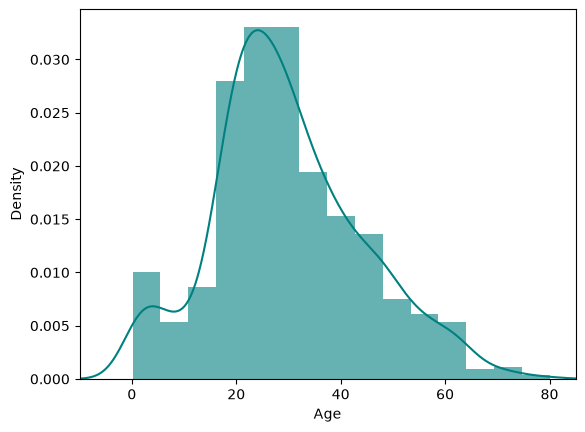

In [8]:
ax = df["Age"].hist(bins=15, density=True, stacked=True, color='teal', alpha=0.6)
df["Age"].plot(kind='density', color='teal')
ax.set(xlabel='Age')
plt.xlim(-10,85)
plt.show()

In [9]:
# mean age
print('Mean of "Age" is %.2f' %(df["Age"].mean(skipna=True)))
# median age
print('Median of "Age" is %.2f' %(df["Age"].median(skipna=True)))


Mean of "Age" is 29.88
Median of "Age" is 28.00


In [10]:
#Fill missing values - we'll use the median since the data is right skewed.
df["Age"] = df["Age"].fillna(df["Age"].median())
df["Fare"] = df["Fare"].fillna(df["Fare"].median())

In [11]:
# percent of missing "Cabin" 
print('Percent missing in "Cabin" column: %.2f%%' %((df['Cabin'].isnull().sum()/df.shape[0])*100)) 

Percent missing in "Cabin" column: 77.46%


In [12]:
#Add a new column for HasCabin
df["HasCabin"] = df.Cabin.notnull()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False


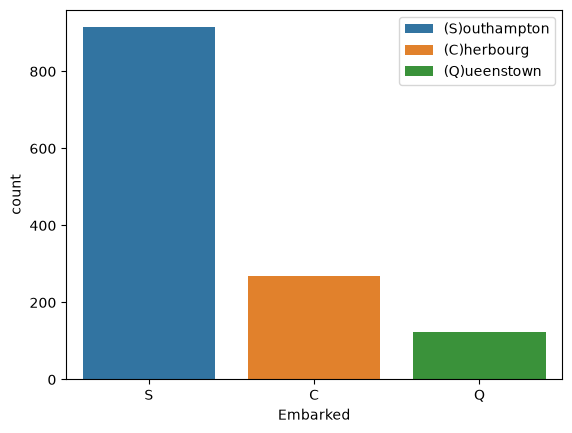

In [13]:
# C = Cherbourg, Q = Queenstown, S = Southampton
sns.countplot(x='Embarked', data=df, hue='Embarked')
# set legend to C = Cherbourg, Q = Queenstown, S = Southampton
plt.legend(['(S)outhampton', '(C)herbourg', '(Q)ueenstown'])
plt.show()

In [14]:
# We'll fill them with the most common value, which is "S".
df["Embarked"] = df["Embarked"].fillna("S")

In [15]:
#Lets add a new column called Title (regex101.com)
df['Title'] = df.Name.apply(lambda x: re.search(' ([A-Z][a-z]+)\.', x).group(1)) 

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
/var/folders/79/xhzr2z1n5_x42g8l6fq1ynvm0000gn/T/ipykernel_84948/3149641519.py:2: SyntaxWarning: invalid escape sequence '\.'
  df['Title'] = df.Name.apply(lambda x: re.search(' ([A-Z][a-z]+)\.', x).group(1))


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17],
 [Text(0, 0, 'Mr'),
  Text(1, 0, 'Mrs'),
  Text(2, 0, 'Miss'),
  Text(3, 0, 'Master'),
  Text(4, 0, 'Don'),
  Text(5, 0, 'Rev'),
  Text(6, 0, 'Dr'),
  Text(7, 0, 'Mme'),
  Text(8, 0, 'Ms'),
  Text(9, 0, 'Major'),
  Text(10, 0, 'Lady'),
  Text(11, 0, 'Sir'),
  Text(12, 0, 'Mlle'),
  Text(13, 0, 'Col'),
  Text(14, 0, 'Capt'),
  Text(15, 0, 'Countess'),
  Text(16, 0, 'Jonkheer'),
  Text(17, 0, 'Dona')])

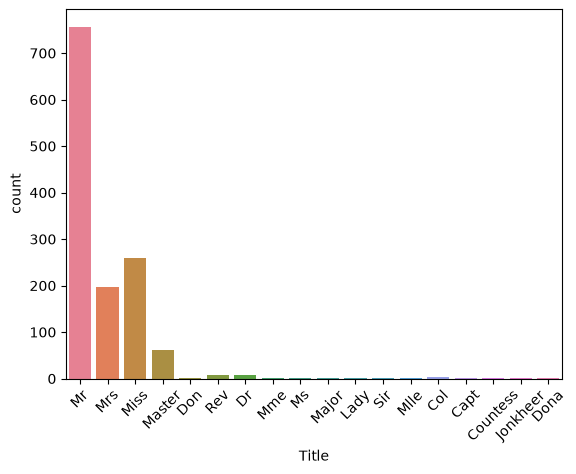

In [16]:
sns.countplot(x='Title', data=df, hue='Title');
plt.xticks(rotation=45)

In [17]:
df["Title"].value_counts()

Title
Mr          757
Miss        260
Mrs         197
Master       61
Rev           8
Dr            8
Col           4
Ms            2
Major         2
Mlle          2
Don           1
Mme           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Dona          1
Name: count, dtype: int64

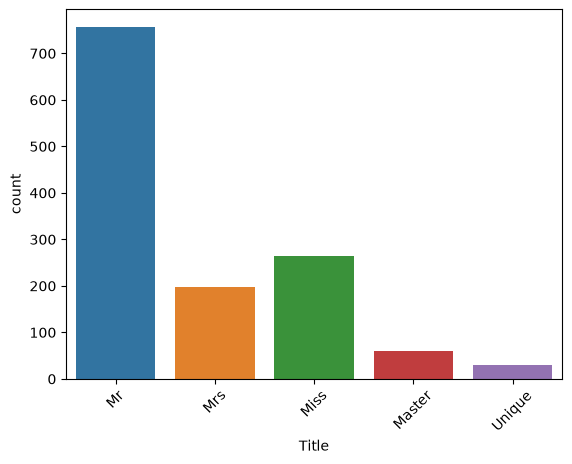

In [18]:
# Grouping titles to
df['Title'] = df['Title'].replace({'Mlle':'Miss', 'Mme':'Mrs', 'Ms':'Miss'})
df['Title'] = df['Title'].replace(['Don', 'Dona', 'Rev', 'Dr',
                                            'Major', 'Lady', 'Sir', 'Col', 'Capt', 'Countess', 'Jonkheer'],'Unique')
sns.countplot(x='Title', data=df, hue='Title');
plt.xticks(rotation=45);

In [19]:
# Creating numerical columns for age and fare
# qcut is used to discretize variables into equal-sized buckets, in order to create a categorical variable
# Think of it as creating 4 bins of age range 0, 1, 2, 3
df['CatAge'] = pd.qcut(df.Age, q=4, labels=False)
df['CatFare']= pd.qcut(df.Fare, q=4, labels=False)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,HasCabin,Title,CatAge,CatFare
0,1,0.0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,Mr,0,0
1,2,1.0,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,Mrs,3,3
2,3,1.0,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,Miss,1,1
3,4,1.0,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,Mrs,2,3
4,5,0.0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,Mr,2,1


In [20]:
#Dropping columns that wont make sense in binary format
df = df.drop(["PassengerId", "Age", "Fare", "Cabin", "Name", "Ticket"], axis=1)
df.head()

,Survived,Pclass,Sex,SibSp,Parch,Embarked,HasCabin,Title,CatAge,CatFare
0,0.0,3,male,1,0,S,False,Mr,0,0
1,1.0,1,female,1,0,C,True,Mrs,3,3
2,1.0,3,female,0,0,S,False,Miss,1,1
3,1.0,1,female,1,0,S,True,Mrs,2,3
4,0.0,3,male,0,0,S,False,Mr,2,1


In [21]:
# Converting to binary values
df_dum = pd.get_dummies(df, drop_first=True)
df_dum.head()

,Survived,Pclass,SibSp,Parch,HasCabin,CatAge,CatFare,Sex_male,Embarked_Q,Embarked_S,Title_Miss,Title_Mr,Title_Mrs,Title_Unique
0,0.0,3,1,0,False,0,0,True,False,True,False,True,False,False
1,1.0,1,1,0,True,3,3,False,False,False,False,False,True,False
2,1.0,3,0,0,False,1,1,False,False,True,True,False,False,False
3,1.0,1,1,0,True,2,3,False,False,True,False,False,True,False
4,0.0,3,0,0,False,2,1,True,False,True,False,True,False,False


In [22]:
df_dum.to_csv('data/Titanic_Cleaned.csv', index=False)